In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import mediapipe as mp
from keras import layers
import seaborn as sns
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, AdamW
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model
from mediapipe.tasks.python.vision import face_landmarker


In [2]:
import torch
torch.cuda.is_available()

True

In [17]:
# FaceLandmarker
base_options = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
detector = vision.FaceLandmarker.create_from_options(options)

# TRAIN_DATA_PATH = os.path.join("../affectnet_dataset/Train")
# TRAIN_DATA_PATH = os.path.join("../clahe_dataset/Train")
TRAIN_DATA_PATH = os.path.join("../mask_dataset/Train")
TEST_DATA_PATH = os.path.join("../affectnet_dataset/Test")
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_weighted_model.h5"

keypoints_dir = "../keypoints_affectnet"
# keypoints_clahe_dir = "../clahe_keypoints"
keypoints_mask_dir = "../mask_keypoints"
os.makedirs(keypoints_dir, exist_ok=True)
# os.makedirs(keypoints_clahe_dir, exist_ok=True)
os.makedirs(keypoints_mask_dir, exist_ok=True)
data_dirs = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}

In [18]:

def extract_keypoints(results):
    if results.face_landmarks:
        face = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
        )

        # center
        center = face.mean(axis=0)
        face = face - center

        # scale normalize
        scale = np.linalg.norm(face.max(axis=0) - face.min(axis=0))
        if scale != 0:
            face = face / scale

        return face.flatten()
    else:
        return np.zeros(478 * 3)

In [19]:
for split, split_dir in data_dirs.items():
    LANDMARKS = 478
    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        save_class_path = os.path.join(keypoints_mask_dir, split, class_name)
        os.makedirs(save_class_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue

            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img,IMG_SIZE)

            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

            results = detector.detect(mp_image)

            if results.face_landmarks:
                face_landmarks = results.face_landmarks[0]
                if (len(face_landmarks) == LANDMARKS):
                    keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
                else:
                    continue
            else:
               continue

            save_path = os.path.join(
                save_class_path,
                img_name.split('.')[0] + ".npy"
            )
            np.save(save_path, keypoints)

print("Keypoints saved in folder:", keypoints_mask_dir)

Keypoints saved in folder: ../mask_keypoints


In [20]:
train_dataset = ImageDataGenerator().flow_from_directory(
    TRAIN_DATA_PATH,
)
train_counts = {}
CLASSES = list(train_dataset.class_indices.keys())

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

Found 16108 images belonging to 8 classes.
{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [21]:
# folder = "../keypoints_affectnet/train/contempt"
# folder = "../clahe_keypoints/train/contempt"
folder = "../mask_keypoints/train/contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(478, 3)


In [22]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

# X, y = load_keypoints_dataset("../keypoints_affectnet/train")
# X, y = load_keypoints_dataset("../clahe_keypoints/train")
X, y = load_keypoints_dataset("../mask_keypoints/train")


le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

# THEN standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

# (12830, 1434) (12830, 8)
# number of samples - 12830
# number of features per sample - 1434 (478 features * 3 x,y,z coordinates)

(12785, 1434) (12785, 8)


In [23]:
# Weight parameter in CrossEntropyLoss function to apply a weight to each class based on its frequency
y_labels = np.argmax(y_train, axis=1)
# class weights will be given by
# n_samples / (n_classes * np.bincount(y))
# np.bincount counts the occurrences of value in an input array
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
weights = dict(zip(np.unique(y_labels), class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.3509087066779375), np.int64(1): np.float64(1.2774780175859313), np.int64(2): np.float64(1.6526628748707342), np.int64(3): np.float64(1.3339941569282137), np.int64(4): np.float64(0.850971778487753), np.int64(5): np.float64(0.7388465094775775), np.int64(6): np.float64(0.654969262295082), np.int64(7): np.float64(0.9373167155425219)}


In [24]:
model = tf.keras.Sequential([
    layers.Input(shape=(1434,)),
    
    # Block 1
    layers.Dense(1024, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.Dropout(0.2),

    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(8, activation='softmax')
])

model.compile(optimizer=AdamW(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     1,469,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,172,872 (8.29 MB)

 Trainable params: 2,170,056 (8.28 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [25]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,    
    min_lr=1e-6
)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [26]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger,rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3457 - loss: 1.9440

400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4023 - loss: 1.7770 - val_accuracy: 0.4514 - val_loss: 1.5533 - learning_rate: 0.0010
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4553 - loss: 1.6363

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4716 - loss: 1.5918 - val_accuracy: 0.5170 - val_loss: 1.4114 - learning_rate: 0.0010
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4955 - loss: 1.5010 - val_accuracy: 0.5161 - val_loss: 1.3731 - learning_rate: 0.0010
Epoch 4/100
396/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5000 - loss: 1.4640

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5033 - loss: 1.4534 - val_accuracy: 0.5605 - val_loss: 1.2722 - learning_rate: 0.0010
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5213 - loss: 1.4036 - val_accuracy: 0.5217 - val_loss: 1.3397 - learning_rate: 0.0010
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5250 - loss: 1.3861 - val_accuracy: 0.5443 - val_loss: 1.2688 - learning_rate: 0.0010
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5319 - loss: 1.3691 - val_accuracy: 0.5574 - val_loss: 1.2490 - learning_rate: 0.0010
Epoch 8/100
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5319 - loss: 1.3522

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5323 - loss: 1.3464 - val_accuracy: 0.5668 - val_loss: 1.2140 - learning_rate: 0.0010
Epoch 9/100
397/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5380 - loss: 1.3390

...

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6136 - loss: 1.1334 - val_accuracy: 0.6318 - val_loss: 1.0380 - learning_rate: 3.0000e-04
Epoch 28/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6108 - loss: 1.1254 - val_accuracy: 0.6290 - val_loss: 1.0476 - learning_rate: 3.0000e-04
Epoch 29/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6120 - loss: 1.1300 - val_accuracy: 0.6293 - val_loss: 1.0349 - learning_rate: 3.0000e-04
Epoch 30/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6091 - loss: 1.1223 - val_accuracy: 0.6268 - val_loss: 1.0346 - learning_rate: 3.0000e-04
Epoch 31/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6149 - loss: 1.1147 - val_accuracy: 0.6209 - val_loss: 1.0566 - learning_rate: 3.0000e-04
Epoch 32/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6170 - loss: 1.1180 - val_accuracy: 0.6287 - val_loss: 1.0270 - learning_rate: 3.0000e-04
Epoch 33/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - ac

400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6199 - loss: 1.1105 - val_accuracy: 0.6343 - val_loss: 1.0189 - learning_rate: 3.0000e-04
Epoch 35/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6138 - loss: 1.1089 - val_accuracy: 0.6337 - val_loss: 1.0386 - learning_rate: 3.0000e-04
Epoch 36/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6206 - loss: 1.1073 - val_accuracy: 0.6243 - val_loss: 1.0272 - learning_rate: 3.0000e-04
Epoch 37/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6224 - loss: 1.1008 - val_accuracy: 0.6259 - val_loss: 1.0479 - learning_rate: 3.0000e-04
Epoch 38/100
399/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6226 - loss: 1.0967

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6336 - loss: 1.0711 - val_accuracy: 0.6422 - val_loss: 0.9991 - learning_rate: 9.0000e-05
Epoch 39/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6348 - loss: 1.0639 - val_accuracy: 0.6368 - val_loss: 1.0006 - learning_rate: 9.0000e-05
Epoch 40/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6358 - loss: 1.0658 - val_accuracy: 0.6409 - val_loss: 1.0019 - learning_rate: 9.0000e-05
Epoch 41/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6344 - loss: 1.0590 - val_accuracy: 0.6393 - val_loss: 0.9949 - learning_rate: 9.0000e-05
Epoch 42/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6346 - loss: 1.0554 - val_accuracy: 0.6378 - val_loss: 0.9952 - learning_rate: 9.0000e-05
Epoch 43/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6364 - loss: 1.0531 - val_accuracy: 0.6384 - val_loss: 0.9972 - learning_rate: 9.0000e-05
Epoch 44/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - ac

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6409 - loss: 1.0387 - val_accuracy: 0.6431 - val_loss: 0.9908 - learning_rate: 2.7000e-05
Epoch 50/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6478 - loss: 1.0247 - val_accuracy: 0.6403 - val_loss: 0.9893 - learning_rate: 8.1000e-06
Epoch 51/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6542 - loss: 1.0183

400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6491 - loss: 1.0245 - val_accuracy: 0.6440 - val_loss: 0.9882 - learning_rate: 8.1000e-06
Epoch 52/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6491 - loss: 1.0254 - val_accuracy: 0.6419 - val_loss: 0.9879 - learning_rate: 8.1000e-06
Epoch 53/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6439 - loss: 1.0327 - val_accuracy: 0.6428 - val_loss: 0.9877 - learning_rate: 2.4300e-06
Epoch 54/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6512 - loss: 1.0237 - val_accuracy: 0.6412 - val_loss: 0.9877 - learning_rate: 2.4300e-06
Epoch 55/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6469 - loss: 1.0259 - val_accuracy: 0.6409 - val_loss: 0.9904 - learning_rate: 2.4300e-06
Epoch 56/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6467 - loss: 1.0271 - val_accuracy: 0.6415 - val_loss: 0.9870 - learning_rate: 1.0000e-06
Epoch 57/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - ac

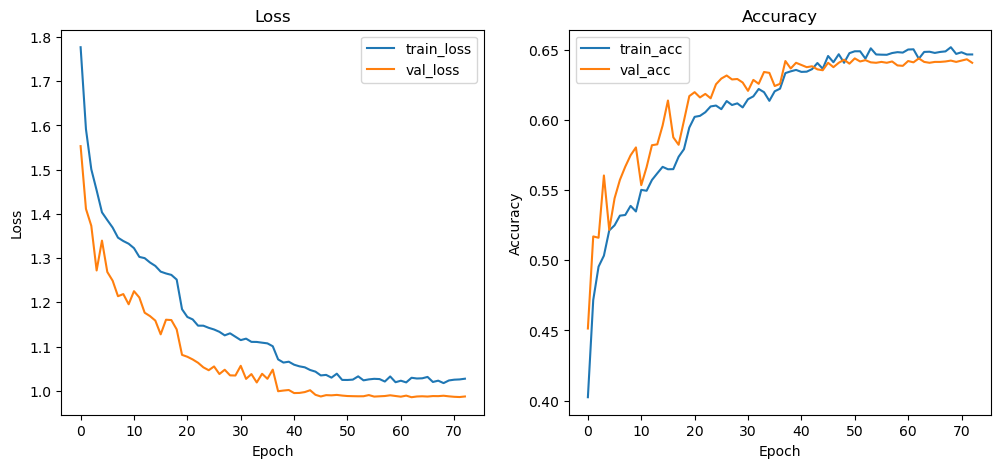

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [28]:
model = load_model(SAVED_MODEL)

In [29]:
# load test data
X_test, y_test = load_keypoints_dataset("../keypoints_affectnet/test")

X_test = X_test.reshape(X_test.shape[0], -1)
# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_test shape: (14480, 1434)
y_test_cat shape: (14480, 8)


In [30]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = np.argmax(y_test_cat, axis=1)  # one-hot

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytrue, yhat)
print(f"Test Accuracy: {acc*100:.2f}%")

Test Accuracy: 63.10%


Evaluating on Test Set...
Test Accuracy: 63.10%
Generating predictions...

Classification Report:

              precision    recall  f1-score   support

       anger       0.53      0.41      0.46      1705
    contempt       0.56      0.67      0.61      1312
     disgust       0.41      0.48      0.44      1243
        fear       0.55      0.42      0.48      1658
       happy       0.91      0.90      0.90      2703
     neutral       0.72      0.95      0.82      2367
         sad       0.52      0.54      0.53      1576
    surprise       0.51      0.39      0.44      1916

    accuracy                           0.63     14480
   macro avg       0.59      0.59      0.59     14480
weighted avg       0.62      0.63      0.62     14480



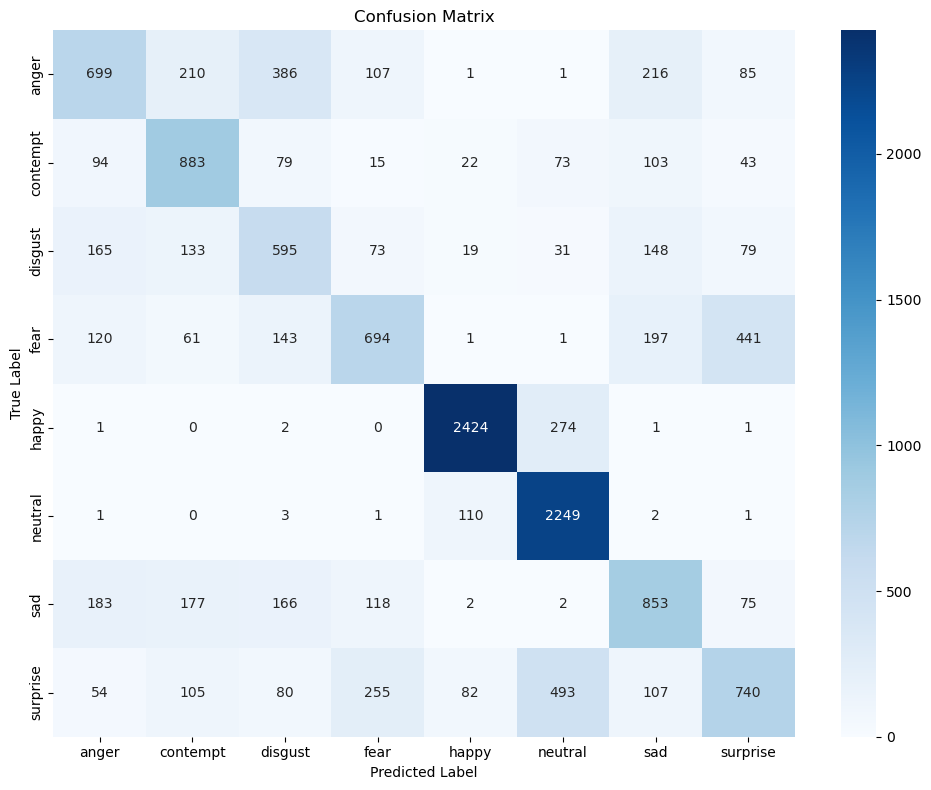

In [32]:
def report_test_results_keypoints(X_test, y_test_cat, y_test_enc, model, le):
    print("Evaluating on Test Set...")
    
    loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    print("Generating predictions...")
    predictions = model.predict(X_test, verbose=0)
    y_pred_indices = np.argmax(predictions, axis=1)

    class_labels = le.classes_

    print("\nClassification Report:\n")
    print(classification_report(
        y_test_enc,
        y_pred_indices,
        target_names=class_labels
    ))

    cm = confusion_matrix(y_test_enc, y_pred_indices)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

report_test_results_keypoints(X_test, y_test_cat, y_test_enc, model, le)

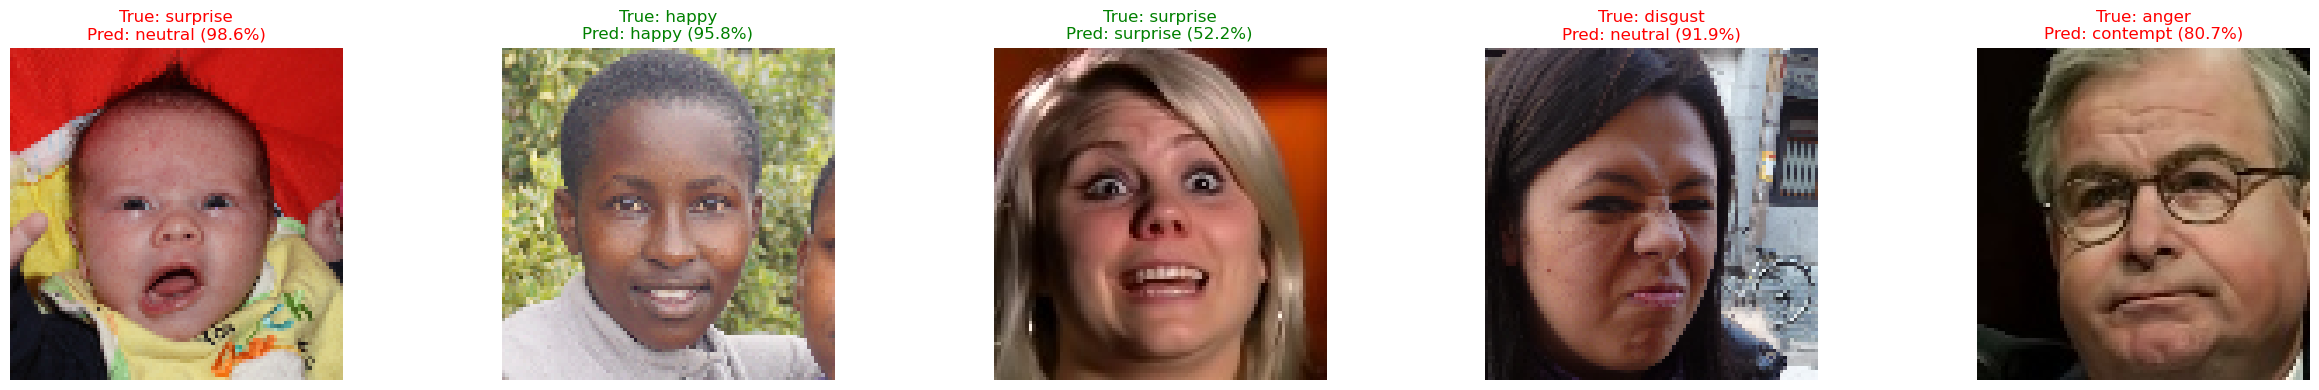

In [35]:
def predict_images_with_keypoints(image_dir, model, scaler, le, n=5):
    images_paths = []

    # collect all images
    for class_name in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue
            images_paths.append((os.path.join(class_path, img_name), class_name))

    # pick random samples
    samples = np.random.choice(len(images_paths), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for i, idx in enumerate(samples):
        img_path, true_label = images_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- KEYPOINT EXTRACTION ---
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results = detector.detect(mp_image)

        if not results.face_landmarks:
            pred_label = "No face"
            confidence = 0
        else:
            face_landmarks = results.face_landmarks[0]

            keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            keypoints = keypoints.reshape(1, -1)

            keypoints = scaler.transform(keypoints)

            pred_prob = model.predict(keypoints, verbose=0)[0]
            pred_idx = np.argmax(pred_prob)
            pred_label = le.classes_[pred_idx]
            confidence = pred_prob[pred_idx] * 100

        axes[i].imshow(img_rgb)
        axes[i].axis("off")

        color = "green" if pred_label == true_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_images_with_keypoints(
    "../affectnet_dataset/Test",
    model,
    scaler,
    le,
    n=5
)